# 시각화 모음 — LoL 승패 예측·설명 서비스
**4조 · 발표용 그림 한 곳에 모음**

`reports/` 폴더의 **CSV를 읽어 그림을 다시 그립니다.** 그래서 색·크기·라벨을 바꾸고 싶으면
해당 셀만 고쳐서 다시 실행하면 됩니다. 그림은 `reports/viz_*.png` 로 저장됩니다.

| 이 노트북이 쓰는 CSV | 무엇이 들어있나 | 만든 스크립트 |
|---|---|---|
| `win_factor_ranking.csv` | 피처 13개의 계수·permutation 중요도 | `finalize_model.py` |
| `day4_error_analysis.csv` | 골드차 구간별 홀드아웃 정확도 | `finalize_model.py` |
| `day2b_game_type_profile.csv` | 경기 유형 4가지 프로파일 | `day2b_game_types.py` |
| `expB_coef_shift.csv` | 10분 vs 15분 계수 변화 | `timepoint_compare.py` |
| `expB_close_games.csv` | 10분 상황별 5분 추가 효과 | `timepoint_compare.py` |
| `repeat_experimentA.csv` | 시드 10개 반복 (실험 A) | `repeat_check.py` |
| `repeat_experimentB.csv` | 시드 10개 반복 (실험 B) | `repeat_check.py` |

> CSV가 없으면 위 스크립트를 먼저 실행하세요. 위에서 아래로 순서대로 실행합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지 (Windows)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
# 프로젝트 폴더를 자동으로 찾는다 — 노트북을 어디서 열든 동작하게.
# (notebooks/ 에서 열든, 프로젝트 루트에서 열든, 복사해서 다른 데서 열든)
from pathlib import Path
root = Path.cwd()
for _ in range(5):                       # 위로 5단계까지 올라가며 찾는다
    # predict.py 까지 함께 확인한다 — reports 라는 이름의 다른 폴더에 속지 않도록
    if (root / "reports").is_dir() and (root / "predict.py").is_file():
        break
    root = root.parent
else:
    raise FileNotFoundError(
        "reports 폴더를 찾지 못했습니다. 이 노트북을 프로젝트 폴더 안에서 열어주세요.")
R = str(root / "reports")
print("프로젝트 폴더:", root)
BLUE, RED, GRAY = "#3182ce", "#e53e3e", "#a0aec0"
print("준비 완료")

프로젝트 폴더: C:\AI 캠퍼스 MLOps양성과정\ML\ML실습\4조_LoL 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석
준비 완료


## 1. 승리요인 — 무엇이 승패를 가르나

두 가지 방법으로 각각 중요도를 재고, **둘 다 상위인 것만** 진짜 요인으로 인정했습니다.
- **표준화 계수**: 그 값이 1만큼 오르면 승률이 얼마나 오르나 (방향 +/− 있음)
- **permutation 중요도**: 그 열을 뒤섞었을 때 정확도가 얼마나 떨어지나

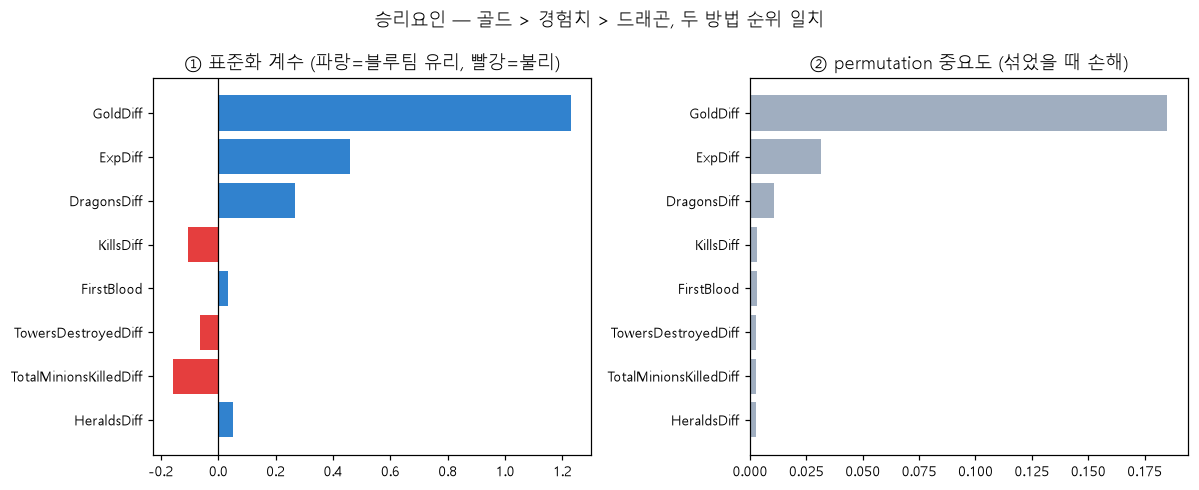

,coef_std,coef_rank,perm_importance,perm_rank
GoldDiff,1.2314,1,0.1850,1
ExpDiff,0.4610,2,0.0315,2
DragonsDiff,0.2674,3,0.0107,3
KillsDiff,-0.1067,5,0.0031,4


In [2]:
f = pd.read_csv(f"{R}/win_factor_ranking.csv", index_col=0)
top = f.sort_values("perm_importance", ascending=False).head(8)[::-1]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
colors = [BLUE if v > 0 else RED for v in top["coef_std"]]
ax[0].barh(top.index, top["coef_std"], color=colors)
ax[0].axvline(0, color="black", lw=0.8)
ax[0].set_title("① 표준화 계수 (파랑=블루팀 유리, 빨강=불리)")
ax[1].barh(top.index, top["perm_importance"], color=GRAY)
ax[1].set_title("② permutation 중요도 (섞었을 때 손해)")
for a in ax:
    a.tick_params(labelsize=9)
fig.suptitle("승리요인 — 골드 > 경험치 > 드래곤, 두 방법 순위 일치", fontsize=12)
fig.tight_layout()
fig.savefig(f"{R}/viz_1_win_factors.png", bbox_inches="tight")
plt.show()
f.head(4)

## 2. 오류 분석 — 어떤 경기에서 틀리나

정확도는 하나의 숫자가 아닙니다. **10분 골드차가 얼마나 벌어졌느냐에 따라 완전히 다릅니다.**

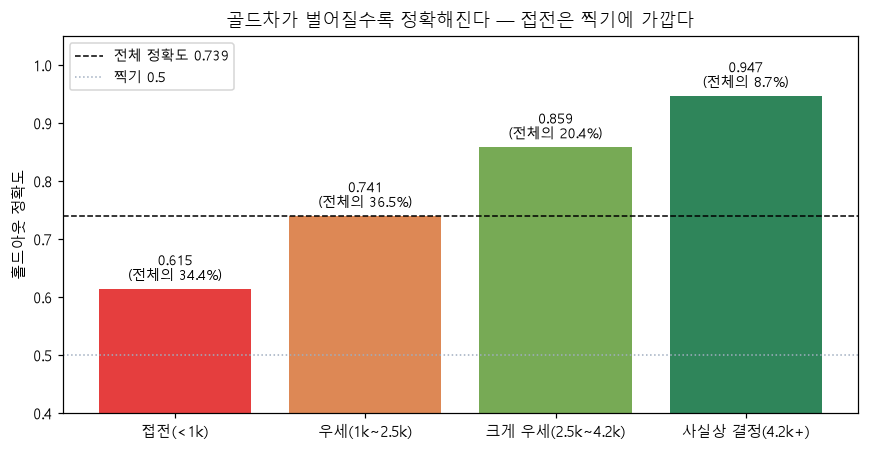

In [3]:
e = pd.read_csv(f"{R}/day4_error_analysis.csv")
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(e["구간"], e["정확도"],
              color=[RED, "#dd8855", "#77aa55", "#2f855a"])
for b, v, w in zip(bars, e["정확도"], e["비중_%"]):
    ax.text(b.get_x() + b.get_width()/2, v + .015,
            f"{v:.3f}\n(전체의 {w}%)", ha="center", fontsize=9)
ax.axhline(0.7394, color="black", ls="--", lw=1, label="전체 정확도 0.739")
ax.axhline(0.5, color=GRAY, ls=":", lw=1, label="찍기 0.5")
ax.set_ylim(0.4, 1.05); ax.set_ylabel("홀드아웃 정확도"); ax.legend(fontsize=9)
ax.set_title("골드차가 벌어질수록 정확해진다 — 접전은 찍기에 가깝다")
fig.tight_layout(); fig.savefig(f"{R}/viz_2_error_analysis.png", bbox_inches="tight")
plt.show()

## 3. 경기 유형 4가지 — 누가 이기는지 지우고 묶어보면

"어느 팀이 유리한가"를 지우고 **경기의 성격**(얼마나 기울었나·얼마나 싸웠나 등)만으로 묶었습니다.

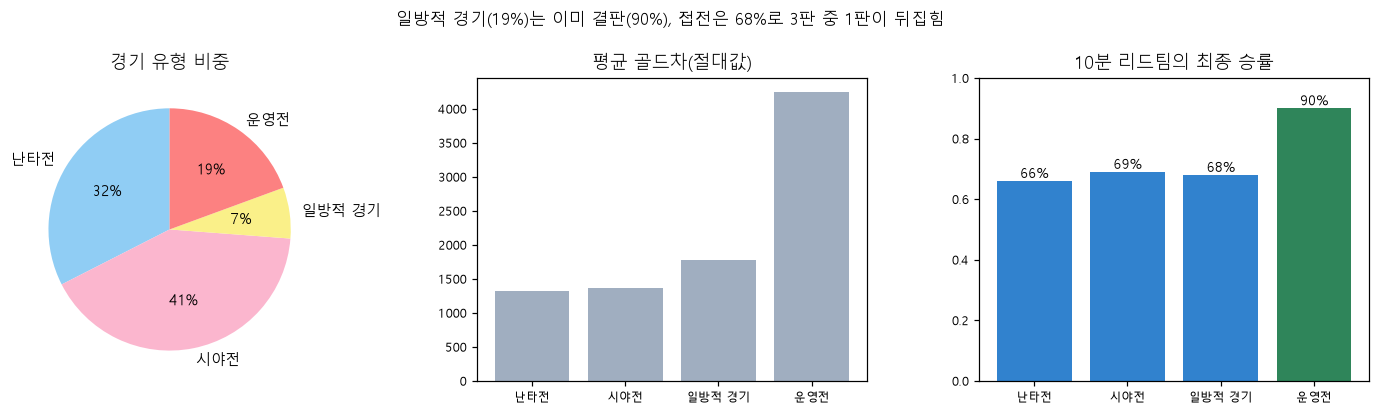

In [4]:
g = pd.read_csv(f"{R}/day2b_game_type_profile.csv")
names = {1: "운영전", 3: "난타전", 0: "시야전", 2: "일방적 경기"}
g["유형"] = g["cluster"].map(names)
g = g.sort_values("일방성_골드차")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].pie(g["비중_%"], labels=g["유형"], autopct="%1.0f%%", startangle=90,
          colors=["#90cdf4", "#fbb6ce", "#faf089", "#fc8181"])
ax[0].set_title("경기 유형 비중")
ax[1].bar(g["유형"], g["일방성_골드차"], color=GRAY)
ax[1].set_title("평균 골드차(절대값)"); ax[1].tick_params(labelsize=8)
b = ax[2].bar(g["유형"], g["리드팀승률"],
              color=[BLUE if v < .8 else "#2f855a" for v in g["리드팀승률"]])
for bb, v in zip(b, g["리드팀승률"]):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+.01, f"{v:.0%}", ha="center", fontsize=9)
ax[2].set_ylim(0, 1); ax[2].set_title("10분 리드팀의 최종 승률"); ax[2].tick_params(labelsize=8)
fig.suptitle("일방적 경기(19%)는 이미 결판(90%), 접전은 68%로 3판 중 1판이 뒤집힘", fontsize=11)
fig.tight_layout(); fig.savefig(f"{R}/viz_3_game_types.png", bbox_inches="tight")
plt.show()

## 4. 실험 B — 5분을 더 보면 무엇이 달라지나

같은 경기·같은 피처·같은 분할에서 **시점만** 10분 → 15분으로 바꿔 학습한 결과입니다.

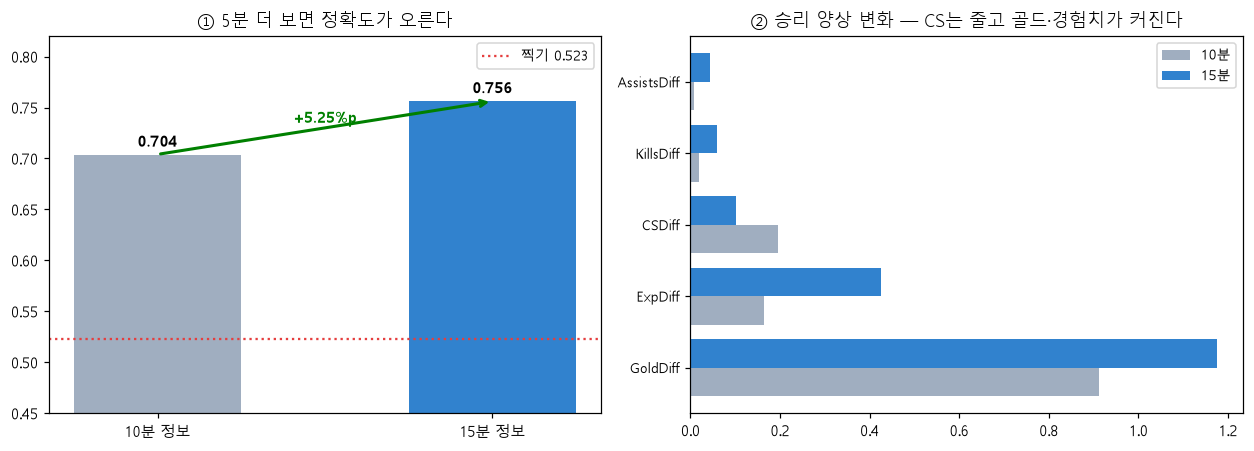

,10분,15분,변화
GoldDiff,0.913,1.175,0.262
ExpDiff,0.165,0.425,0.260
CSDiff,0.196,0.102,-0.094
KillsDiff,0.020,0.059,0.039
AssistsDiff,0.009,0.043,0.034


In [5]:
c = pd.read_csv(f"{R}/expB_coef_shift.csv", index_col=0)
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

# (a) 성능
x = np.arange(2)
ax[0].bar(x, [0.7036, 0.7561], color=[GRAY, BLUE], width=.5)
ax[0].axhline(0.523, color=RED, ls=":", label="찍기 0.523")
for i, v in enumerate([0.7036, 0.7561]):
    ax[0].text(i, v+.008, f"{v:.3f}", ha="center", fontweight="bold")
ax[0].annotate("", xy=(1, 0.756), xytext=(0, 0.704),
               arrowprops=dict(arrowstyle="->", color="green", lw=2))
ax[0].text(.5, .735, "+5.25%p", color="green", ha="center", fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(["10분 정보", "15분 정보"])
ax[0].set_ylim(.45, .82); ax[0].set_title("① 5분 더 보면 정확도가 오른다"); ax[0].legend(fontsize=9)

# (b) 계수 변화
idx = np.arange(len(c))
ax[1].barh(idx-.2, c["10분"], .4, label="10분", color=GRAY)
ax[1].barh(idx+.2, c["15분"], .4, label="15분", color=BLUE)
ax[1].set_yticks(idx); ax[1].set_yticklabels(c.index, fontsize=9)
ax[1].set_title("② 승리 양상 변화 — CS는 줄고 골드·경험치가 커진다")
ax[1].legend(fontsize=9)
fig.tight_layout(); fig.savefig(f"{R}/viz_4_timepoint.png", bbox_inches="tight")
plt.show()
c

## 5. 실험 B 핵심 — 5분이 값어치 있는 것은 접전 경기뿐

**이미 크게 기운 경기는 5분을 더 봐도 얻는 게 0입니다.**

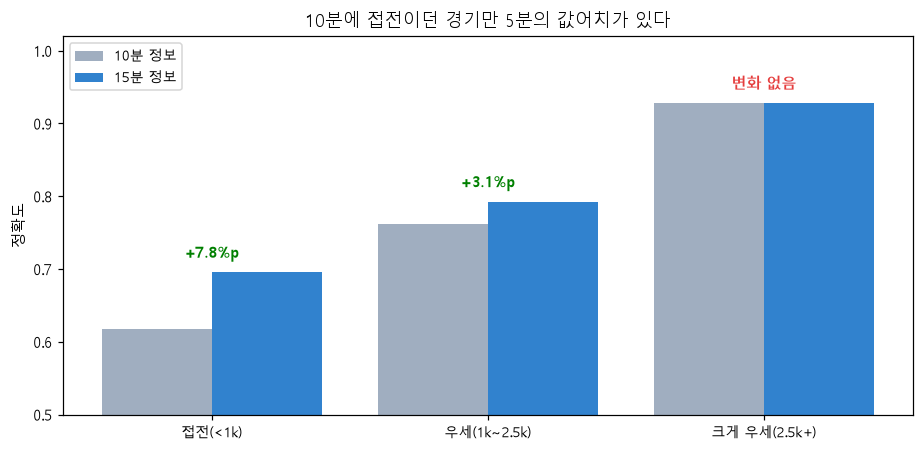

,10분구간,경기수,정확도_10분,정확도_15분,개선,비중_%
0,접전(<1k),1110,0.6171,0.6955,0.0784,52.1
1,우세(1k~2.5k),800,0.7612,0.7925,0.0313,37.5
2,크게 우세(2.5k+),222,0.9279,0.9279,0.0000,10.4


In [6]:
k = pd.read_csv(f"{R}/expB_close_games.csv")
x = np.arange(len(k))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(x-.2, k["정확도_10분"], .4, label="10분 정보", color=GRAY)
ax.bar(x+.2, k["정확도_15분"], .4, label="15분 정보", color=BLUE)
for i, (a_, b_) in enumerate(zip(k["정확도_10분"], k["정확도_15분"])):
    d = b_ - a_
    ax.text(i, max(a_, b_)+.02, f"+{d*100:.1f}%p" if d > 0 else "변화 없음",
            ha="center", fontsize=10,
            color="green" if d > 0.001 else RED, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(k["10분구간"], fontsize=9)
ax.set_ylim(.5, 1.02); ax.legend(fontsize=9); ax.set_ylabel("정확도")
ax.set_title("10분에 접전이던 경기만 5분의 값어치가 있다")
fig.tight_layout(); fig.savefig(f"{R}/viz_5_close_games.png", bbox_inches="tight")
plt.show()
k

## 6. 반복 검증 — 이 결과가 운은 아닌가

데이터를 **다르게 10번 나눠서** 처음부터 다시 학습했습니다(시드 10개).
점들이 좁게 모여 있으면 "운이 아니라 실력"이라는 뜻입니다.

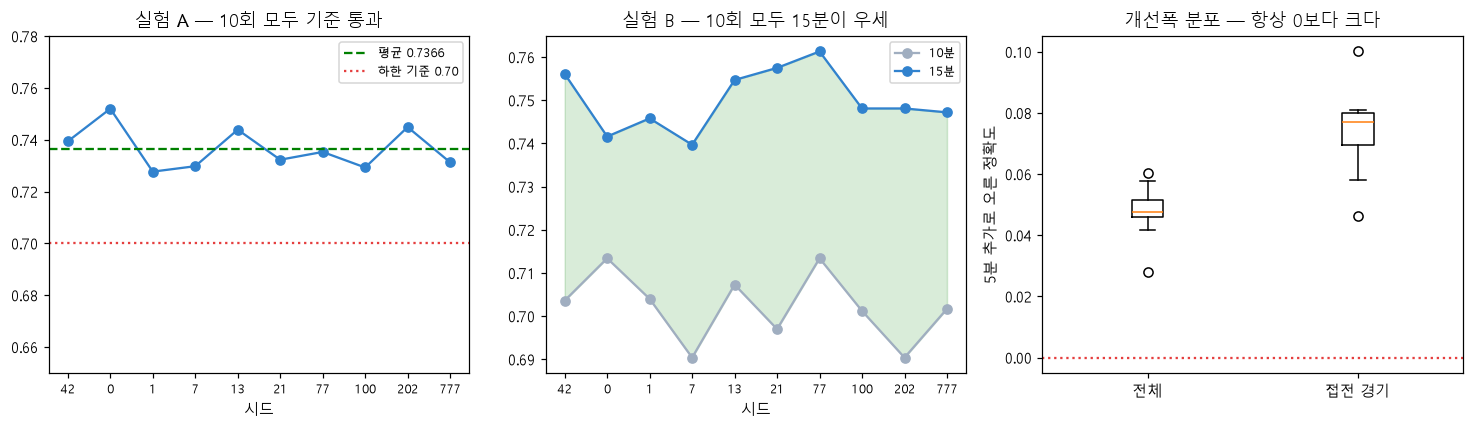

실험 A 정확도 : 0.7366 ± 0.0081  (10/10회 하한 통과)
실험 B 시점효과: +0.0477 ± 0.0089  (10/10회 15분 우세)
  접전 개선폭 : +0.0740 ± 0.0144


In [7]:
ra = pd.read_csv(f"{R}/repeat_experimentA.csv")
rb = pd.read_csv(f"{R}/repeat_experimentB.csv")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
# (a) 실험 A 정확도 분포
ax[0].plot(range(10), ra["정확도"], "o-", color=BLUE)
ax[0].axhline(ra["정확도"].mean(), color="green", ls="--",
              label=f"평균 {ra['정확도'].mean():.4f}")
ax[0].axhline(0.70, color=RED, ls=":", label="하한 기준 0.70")
ax[0].set_xticks(range(10)); ax[0].set_xticklabels(ra["seed"], fontsize=8)
ax[0].set_xlabel("시드"); ax[0].set_ylim(.65, .78)
ax[0].set_title("실험 A — 10회 모두 기준 통과"); ax[0].legend(fontsize=8)

# (b) 실험 B 시점 효과
ax[1].plot(range(10), rb["10분"], "o-", color=GRAY, label="10분")
ax[1].plot(range(10), rb["15분"], "o-", color=BLUE, label="15분")
ax[1].fill_between(range(10), rb["10분"], rb["15분"], color="green", alpha=.15)
ax[1].set_xticks(range(10)); ax[1].set_xticklabels(rb["seed"], fontsize=8)
ax[1].set_xlabel("시드")
ax[1].set_title("실험 B — 10회 모두 15분이 우세"); ax[1].legend(fontsize=8)

# (c) 개선폭 분포
ax[2].boxplot([rb["차이"], rb["접전_개선"]], tick_labels=["전체", "접전 경기"])
ax[2].axhline(0, color=RED, ls=":")
ax[2].set_ylabel("5분 추가로 오른 정확도")
ax[2].set_title("개선폭 분포 — 항상 0보다 크다")
fig.tight_layout(); fig.savefig(f"{R}/viz_6_repeat_check.png", bbox_inches="tight")
plt.show()

print("실험 A 정확도 : %.4f ± %.4f  (10/10회 하한 통과)" % (ra["정확도"].mean(), ra["정확도"].std()))
print("실험 B 시점효과: %+.4f ± %.4f  (10/10회 15분 우세)" % (rb["차이"].mean(), rb["차이"].std()))
print("  접전 개선폭 : %+.4f ± %.4f" % (rb["접전_개선"].mean(), rb["접전_개선"].std()))

## 7. 요약 한 장 — 발표 표지용

이 그림 하나로 프로젝트 결론을 다 말할 수 있습니다.

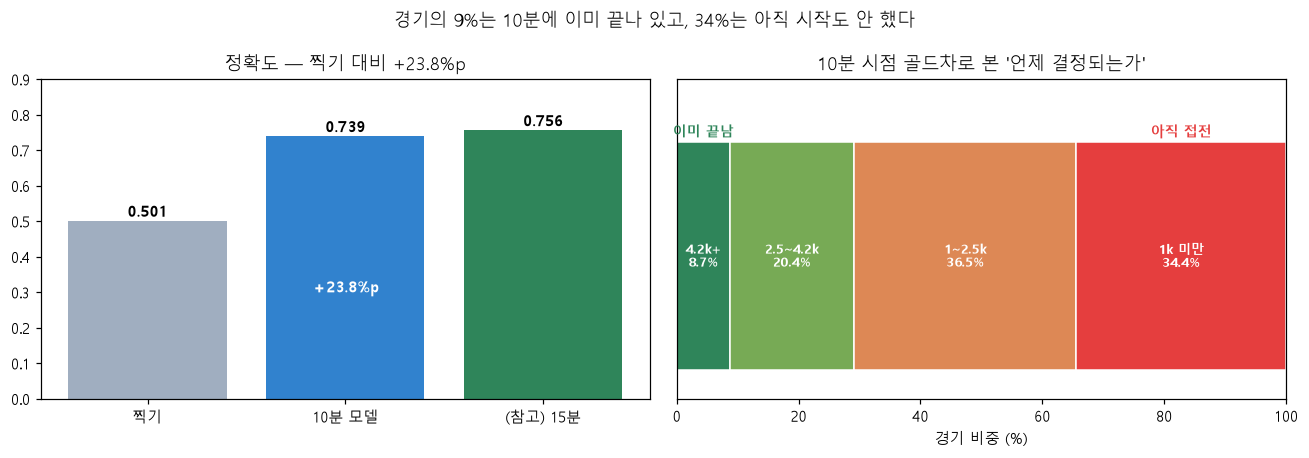

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# 왼쪽: 성능 계단
labels = ["찍기", "10분 모델", "(참고) 15분"]
vals = [0.5010, 0.7394, 0.7561]
b = ax[0].bar(labels, vals, color=[GRAY, BLUE, "#2f855a"])
for bb, v in zip(b, vals):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+.012, f"{v:.3f}",
               ha="center", fontweight="bold")
ax[0].set_ylim(0, .9); ax[0].set_title("정확도 — 찍기 대비 +23.8%p")
ax[0].text(1, .30, "＋23.8%p", ha="center", color="white", fontweight="bold")

# 오른쪽: 언제 결정되는가
seg = [8.7, 20.4, 36.5, 34.4]
lab = ["4.2k+", "2.5~4.2k", "1~2.5k", "1k 미만"]
note = ["이미 끝남", "", "", "아직 접전"]
col = ["#2f855a", "#77aa55", "#dd8855", RED]
left = 0
for s_, l_, n_, c_ in zip(seg, lab, note, col):
    ax[1].barh(0, s_, left=left, color=c_, edgecolor="white")
    ax[1].text(left+s_/2, 0, f"{l_}\n{s_}%", ha="center", va="center",
               fontsize=8.5, color="white", fontweight="bold")
    if n_:   # 좁은 칸은 설명을 막대 위에 따로 적는다
        ax[1].text(left+s_/2, 0.42, n_, ha="center", fontsize=9, color=c_, fontweight="bold")
    left += s_
ax[1].set_ylim(-0.5, 0.62)
ax[1].set_xlim(0, 100); ax[1].set_yticks([]); ax[1].set_xlabel("경기 비중 (%)")
ax[1].set_title("10분 시점 골드차로 본 '언제 결정되는가'")
fig.suptitle("경기의 9%는 10분에 이미 끝나 있고, 34%는 아직 시작도 안 했다", fontsize=12)
fig.tight_layout(); fig.savefig(f"{R}/viz_7_summary.png", bbox_inches="tight")
plt.show()

---
## 저장된 그림

| 파일 | 발표에서 쓸 자리 |
|---|---|
| `viz_1_win_factors.png` | 결과 — 무엇이 승패를 가르나 |
| `viz_2_error_analysis.png` | 결과 — 어떤 경기에서 틀리나 |
| `viz_3_game_types.png` | 결과 — 경기 유형 4가지 |
| `viz_4_timepoint.png` | 실험 B — 5분의 값어치 |
| `viz_5_close_games.png` | 실험 B — 핵심 발견 |
| `viz_6_repeat_check.png` | 신뢰성 — 운이 아니다 |
| `viz_7_summary.png` | **표지·결론 한 장** |

기존 그림(`eda*.png`, `expB_timepoint.png`, `day2b_game_types.png`)도 `reports/` 에 함께 있습니다.